# 📊 Data Visualization with Matplotlib & Seaborn
### A Complete Guide to Charts Used in Data Science

This notebook covers the visualization techniques you'll use most often when exploring data, plus a full descriptive analysis on a messy real-world-style dataset.

---

## What's Inside

| Section | Topic |
|---------|-------|
| 1 | **Univariate Analysis** — understanding one variable at a time |
| 2 | **Bivariate Analysis** — relationships between two variables |
| 3 | **Multivariate Analysis** — three or more variables together |
| 4 | **Descriptive Analysis on a Messy Dataset** — the real-world workflow |

---

## Why Visualization Matters in Data Science

> "A picture is worth a thousand summary statistics."

Numbers like the mean or standard deviation can hide important patterns. Anscombe's Quartet is a famous example: four datasets with **identical** means, variances, and correlations look completely different when plotted. Visualization helps us:

- Understand the **distribution** of variables (skewness, modality, outliers)
- Spot **relationships** between variables (linear, non-linear, none)
- Detect **data quality issues** (missing values, errors, duplicates)
- Communicate **insights** to non-technical audiences


## 🔧 Setup

We import the standard data science visualization stack:
- **matplotlib** — the foundational plotting library
- **seaborn** — built on matplotlib, gives prettier defaults and statistical plots
- **pandas** — for data manipulation
- **numpy** — for numerical operations


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Style configuration
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Reproducibility
np.random.seed(42)
print("Libraries loaded. matplotlib:", plt.matplotlib.__version__, "| seaborn:", sns.__version__)

Libraries loaded. matplotlib: 3.11.0 | seaborn: 0.13.2


### 🎨 Understanding the Styling Configuration Above

That setup block is a **global configuration** — you set styling defaults once at the top of the notebook, and every chart afterwards inherits the look. Without it, matplotlib falls back to its built-in defaults (small figures, small fonts, plain background) which feel cramped in a notebook.

#### Line by line

| Line | What it does |
|------|--------------|
| `sns.set_style('whitegrid')` | Sets seaborn's background theme. `'whitegrid'` gives a white background with light grey gridlines that help readers eyeball values without the gridlines stealing attention. Alternatives: `'darkgrid'`, `'white'`, `'dark'`, `'ticks'`. |
| `sns.set_palette('husl')` | Sets the default color cycle for plots with multiple colors (a grouped bar chart, multi-series line plot). `'husl'` spaces colors evenly around the color wheel so adjacent categories stay visually distinct. Other common choices: `'Set2'`, `'pastel'`, `'deep'`, `'viridis'`. |
| `plt.rcParams['figure.figsize'] = (10, 5)` | Sets the default figure size to 10 × 5 inches. Matplotlib's built-in default is about 6.4 × 4.8, which is often too small for notebooks. |
| `plt.rcParams['font.size'] = 11` | Sets the base font used for axis labels, tick labels, and legends. The default is 10. |
| `plt.rcParams['axes.titlesize'] = 13` | Overrides the title font specifically, so titles sit 2pt larger than body text and gain a clear visual hierarchy. |
| `plt.rcParams['axes.titleweight'] = 'bold'` | Makes chart titles bold for additional emphasis, so the eye lands on the title first. |

#### What `rcParams` actually is

The name stands for **"runtime configuration parameters"** — a dictionary holding all of matplotlib's current settings. There are hundreds of keys you can override (`lines.linewidth`, `axes.edgecolor`, `xtick.color`, `legend.frameon`, and so on), and any change persists for the rest of the session. Both seaborn lines tweak the same underlying `rcParams` internally — seaborn is built on top of matplotlib, so they cooperate rather than conflict.

#### Why bother with this block at all

**Don't repeat yourself.** Without the block, you'd need to write `figsize=(10, 5)` inside every `plt.subplots()` call, add `fontsize=13, fontweight='bold'` to every `set_title()`, and so on. Six lines of upfront config save dozens of lines of repetition across the notebook.

**Consistency.** When every chart in a report has the same proportions, fonts, and color palette, the reader perceives them as one coherent analysis rather than a pile of disjoint plots. That's mostly aesthetic, but aesthetics drive whether people trust and read your work.

**Polish without effort.** Matplotlib's stock defaults are functional but visually plain — six lines of configuration is the difference between a chart that looks like a 2005 textbook and one that looks like it belongs in a modern report.

#### Useful escape hatches

- `plt.rcdefaults()` — resets matplotlib back to factory defaults mid-notebook
- `sns.reset_defaults()` — undoes the seaborn-specific pieces
- `with plt.rc_context({'figure.figsize': (6, 4)}): ...` — temporarily override settings for just one chart, then revert automatically


### Generate a sample dataset for demonstration

We'll create a synthetic dataset of customers so each chart has data to plot.

In [6]:
n = 500
demo = pd.DataFrame({
    'age': np.random.normal(35, 10, n).clip(18, 70).astype(int),
    'income': np.random.lognormal(10.5, 0.5, n).round(2),
    'spending_score': np.random.beta(2, 5, n) * 100,
    'years_customer': np.random.exponential(3, n).clip(0, 15).round(1),
    'gender': np.random.choice(['Male', 'Female'], n, p=[0.48, 0.52]),
    'city': np.random.choice(['Kathmandu', 'Pokhara', 'Lalitpur', 'Bhaktapur', 'Biratnagar'],
                              n, p=[0.40, 0.20, 0.20, 0.10, 0.10]),
    'plan': np.random.choice(['Basic', 'Standard', 'Premium'], n, p=[0.5, 0.3, 0.2]),
    'satisfaction': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.20, 0.40, 0.25]),
})
# Inject a realistic relationship: spending grows with income
demo['spending_score'] = (demo['spending_score'] + (demo['income'] / 2000)).clip(0, 100)
demo.head()

,age,income,spending_score,years_customer,gender,city,plan,satisfaction
0,39,57704.40,66.503247,4.1,Female,Biratnagar,Basic,5
1,33,94344.51,81.060346,2.0,Male,Lalitpur,Basic,4
2,41,18046.67,42.509027,2.0,Female,Biratnagar,Basic,1
3,50,48121.51,68.055396,5.5,Male,Kathmandu,Basic,4
4,32,26230.52,62.894024,1.3,Female,Lalitpur,Premium,5


In [43]:
demo.dtypes

age                 int64
income            float64
spending_score    float64
years_customer    float64
gender                str
city                  str
plan                  str
satisfaction        int64
dtype: object

---
# 1️⃣ Univariate Analysis — One Variable at a Time

The first step in any data exploration is understanding **each variable on its own**. The chart you reach for depends on whether the variable is:

- **Numerical (continuous)** — age, income, temperature → histograms, box plots, KDE
- **Categorical (discrete)** — gender, city, plan type → bar charts, count plots, pie charts


## 1.1 📊 Histogram

### What it does
A histogram divides a numerical variable into **bins** (intervals) and shows how many observations fall into each one.

### When to use
- You want to see the **shape of a distribution** (normal, skewed, bimodal, uniform)
- You're checking whether a variable is **roughly bell-shaped** (a common assumption for many statistical methods)
- You want to **spot outliers** in the tails

### What to look for
- **Center** — where most values sit (mean / median)
- **Spread** — how wide the distribution is (variance)
- **Skewness** — is it symmetric, or does it have a long tail on one side?
- **Modality** — one peak (unimodal) or multiple peaks (bimodal/multimodal)?


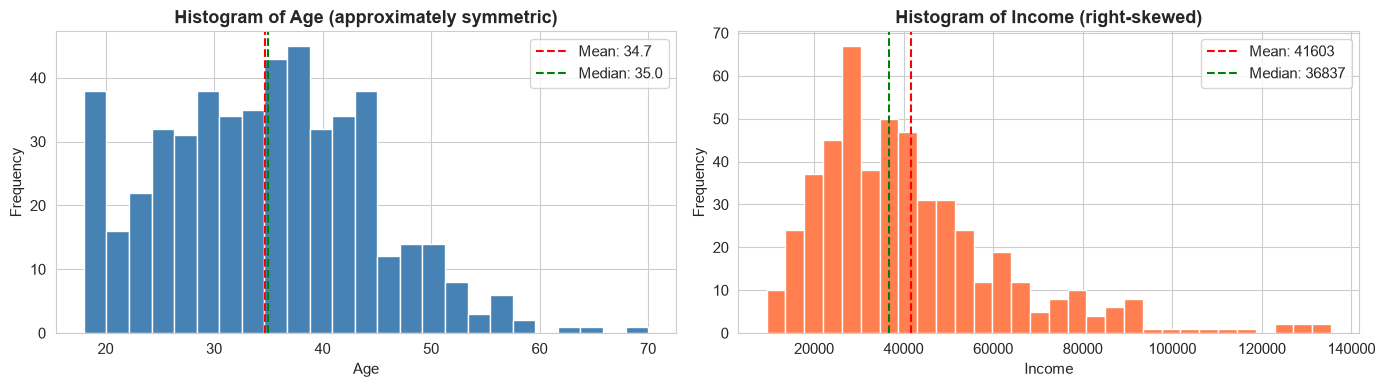

In [60]:
fig, axes = plt.subplots(1,2, figsize=(14, 4))

# Age - roughly normal
axes[0].hist(demo['age'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram of Age (approximately symmetric)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(demo['age'].mean(), color='red', linestyle='--', label=f'Mean: {demo["age"].mean():.1f}')
axes[0].axvline(demo['age'].median(),color='green',linestyle='--',label=f'Median: {demo['age'].median():.1f}')
axes[0].legend()

# Income - right-skewed (lognormal)
axes[1].hist(demo['income'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Histogram of Income (right-skewed)')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Frequency')
axes[1].axvline(demo['income'].mean(), color='red', linestyle='--', label=f'Mean: {demo["income"].mean():.0f}')
axes[1].axvline(demo['income'].median(), color='green', linestyle='--', label=f'Median: {demo["income"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

**Reading the chart:** Age looks symmetric around 35 — the mean and median would be very close. Income is **right-skewed** because a few high earners pull the mean above the median. This is why for skewed data we often report the **median** instead of the mean.

## 1.2 📦 Box Plot (Box-and-Whisker)

### What it does
A box plot summarizes a numerical variable using **five numbers**:
- **Q1** (25th percentile) — bottom of the box
- **Median** (50th percentile) — line inside the box
- **Q3** (75th percentile) — top of the box
- **Whiskers** — typically extend to 1.5× the IQR
- **Dots** beyond the whiskers — **outliers**

### When to use
- You need to **detect outliers** quickly
- You want to **compare distributions** across categories side-by-side
- You're presenting a compact summary in limited space


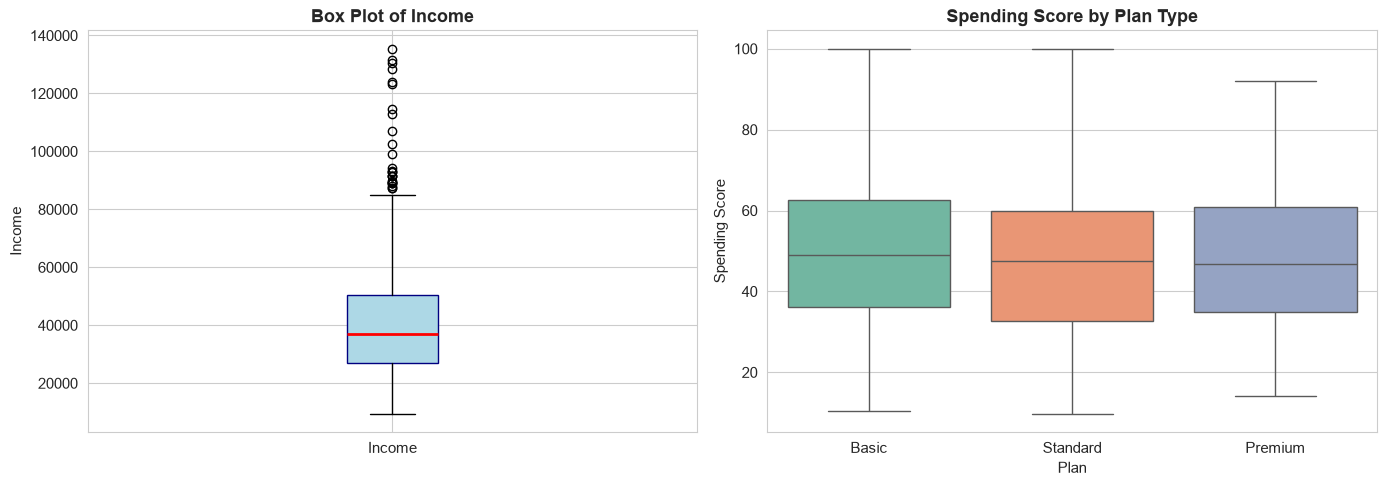

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single variable box plot
axes[0].boxplot(demo['income'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', edgecolor='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Box Plot of Income')
axes[0].set_ylabel('Income')
axes[0].set_xticklabels(['Income'])

# Box plot by category - great for comparison
sns.boxplot(data=demo, x='plan', y='spending_score', ax=axes[1],
            order=['Basic', 'Standard', 'Premium'], palette='Set2')
axes[1].set_title('Spending Score by Plan Type')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Spending Score')

plt.tight_layout()
plt.show()

**Reading the chart:** The dots above the income box are likely outliers — customers earning unusually high amounts. In the right-hand plot, Premium customers spend more on average, and you can see the whole distribution shift up across plan tiers.

## 1.3 〰️ KDE / Density Plot

### What it does
A **Kernel Density Estimate (KDE)** is a smoothed version of a histogram. Instead of bars, it draws a continuous curve estimating the probability density.

### When to use
- You want a **smoother view** of a distribution than a histogram provides
- You need to **compare multiple distributions on the same axes** (histograms get cluttered when overlaid)
- You're presenting to an audience — KDEs are easier on the eye

### Caveats
- The smoothness depends on a **bandwidth** parameter. Too low → noisy; too high → loses detail
- KDEs can suggest density in regions where you have no data — be careful at the tails


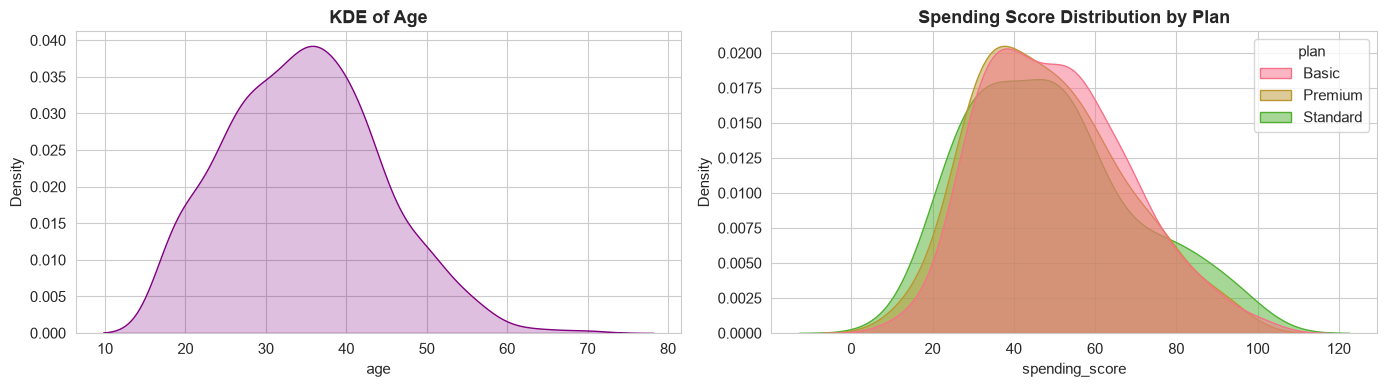

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Single KDE
sns.kdeplot(data=demo, x='age', fill=True, color='purple', ax=axes[0])
axes[0].set_title('KDE of Age')

# KDE comparison across groups
sns.kdeplot(data=demo, x='spending_score', hue='plan', fill=True,
            common_norm=False, alpha=0.5, ax=axes[1])
axes[1].set_title('Spending Score Distribution by Plan')

plt.tight_layout()
plt.show()

**Reading the chart:** The right-hand KDE overlay shows clearly that Premium customers' spending distribution is shifted to the right of Basic customers' — something that would be much harder to see if we overlaid three histograms.

## 1.4 📏 Bar Chart / Count Plot

### What it does
Bars whose **heights represent counts or aggregated values** for each category of a categorical variable.

### When to use
- The variable is **categorical** (city, gender, product type)
- You want to show **frequency** (count plot) or an **aggregate** like average sales per category
- Categories can be ordered (use that order!) or unordered (sort by value for clarity)

### Tip
**Sort bars by their value** when there's no natural order — it makes the chart far easier to read.


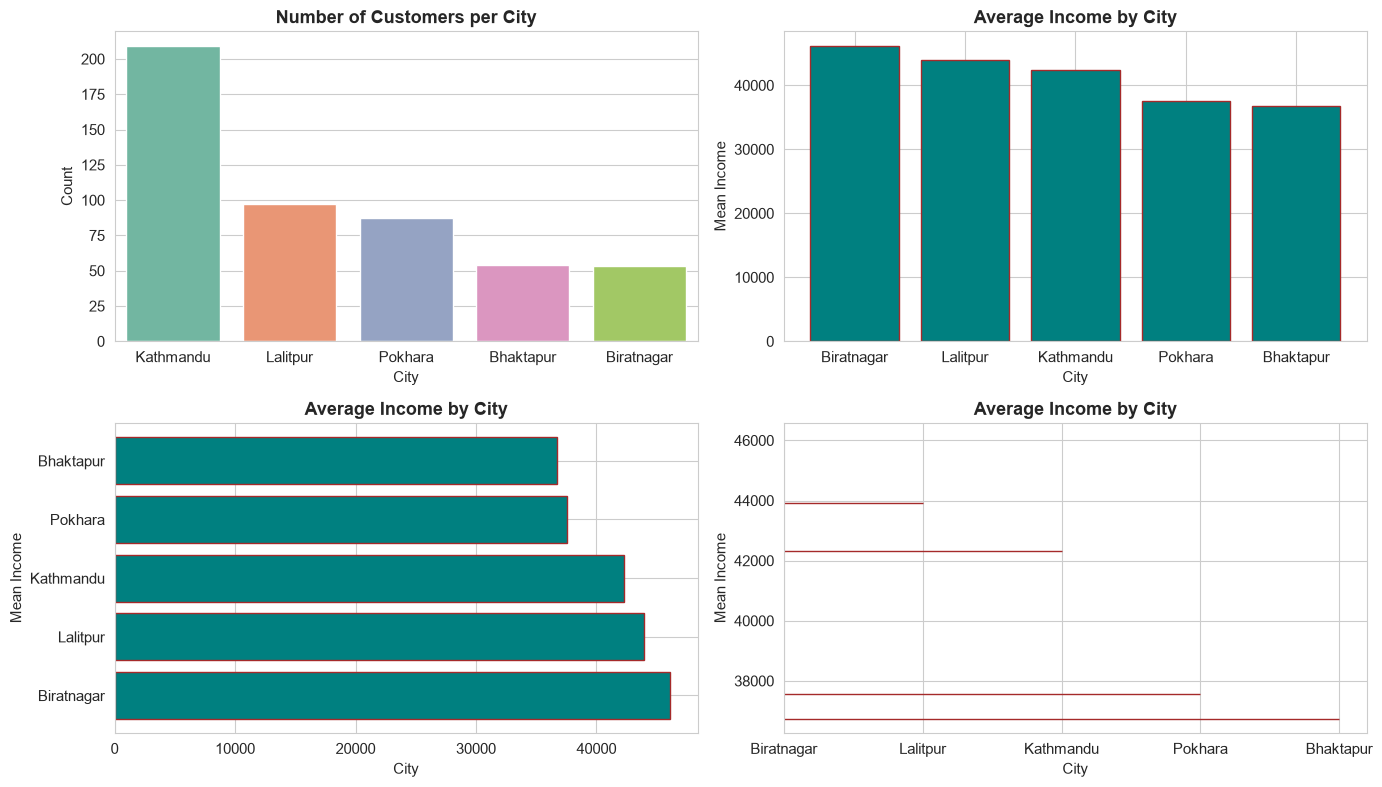

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Count plot - sorted
order = demo['city'].value_counts().index
sns.countplot(data=demo, x='city', order=order, ax=axes[0][0], palette='Set2')
axes[0][0].set_title('Number of Customers per City')
axes[0][0].set_xlabel('City')
axes[0][0].set_ylabel('Count')

# Aggregated bar chart - mean income per city
city_income = demo.groupby('city')['income'].mean().sort_values(ascending=False)
axes[0][1].bar(city_income.index, city_income.values, color='teal', edgecolor='brown')
axes[0][1].set_title('Average Income by City')
axes[0][1].set_xlabel('City')
axes[0][1].set_ylabel('Mean Income')
# plt.tight_layout()
# plt.show()


### NEWLY ADDED CHART
city_income = demo.groupby('city')['income'].mean().sort_values(ascending=False)
axes[1][0].barh(city_income.index,city_income.values, color='teal', edgecolor='brown')
axes[1][0].set_title('Average Income by City')
axes[1][0].set_xlabel('City')
axes[1][0].set_ylabel('Mean Income')
city_income = demo.groupby('city')['income'].mean().sort_values(ascending=False)
axes[1][1].barh(city_income.values,city_income.index, color='teal', edgecolor='brown')
axes[1][1].set_title('Average Income by City')
axes[1][1].set_xlabel('City')
axes[1][1].set_ylabel('Mean Income')
plt.tight_layout()
plt.show()

In [63]:
city_income = demo.groupby('city')['income'].mean().sort_values(ascending=False)
city_income

city
Biratnagar    46102.210189
Lalitpur      43921.577835
Kathmandu     42320.848421
Pokhara       37572.835172
Bhaktapur     36733.056296
Name: income, dtype: float64

In [ ]:
# Aggregated bar chart - mean income per city
city_income = demo.groupby('city')['income'].mean().sort_values(ascending=False)
axes[1].bar(city_income.index, city_income.values, color='teal', edgecolor='brown')
axes[1].set_title('Average Income by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Mean Income')

## 1.5 🥧 Pie Chart

### What it does
A circle divided into slices showing **proportions** of a whole.

### When to use
- You have **few categories** (rule of thumb: ≤ 5)
- You want to emphasize the **part-to-whole relationship**
- One or two slices are dominant and the message is "X is most of the total"

### When NOT to use
- More than 5–6 categories — humans are bad at comparing angles
- Categories of similar size — a bar chart is almost always clearer
- You need precise comparisons — use a bar chart instead


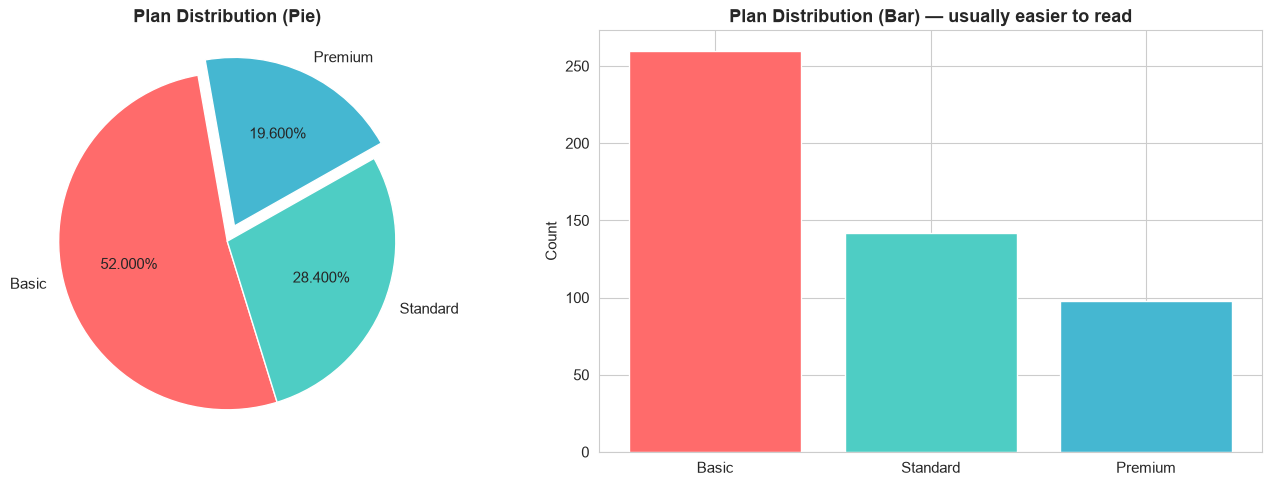

In [106]:
plan_counts = demo['plan'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].pie(plan_counts, labels=plan_counts.index,colors=colors,
            autopct='%1.3f%%', startangle=100, wedgeprops=dict(edgecolor='white', linewidth=1),explode=[0,0,0.1])
axes[0].set_title('Plan Distribution (Pie)')

# Same data as bar - usually clearer
axes[1].bar(plan_counts.index, plan_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Plan Distribution (Bar) — usually easier to read')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 1.6 🎻 Violin Plot

### What it does
A **violin plot = box plot + KDE** mirrored on both sides. The width of the violin at each point shows the density of data at that value.

### When to use
- You want both the **summary statistics** (median, IQR) AND the **shape** of the distribution
- You're comparing distributions across categories and shape matters (e.g., is one bimodal?)


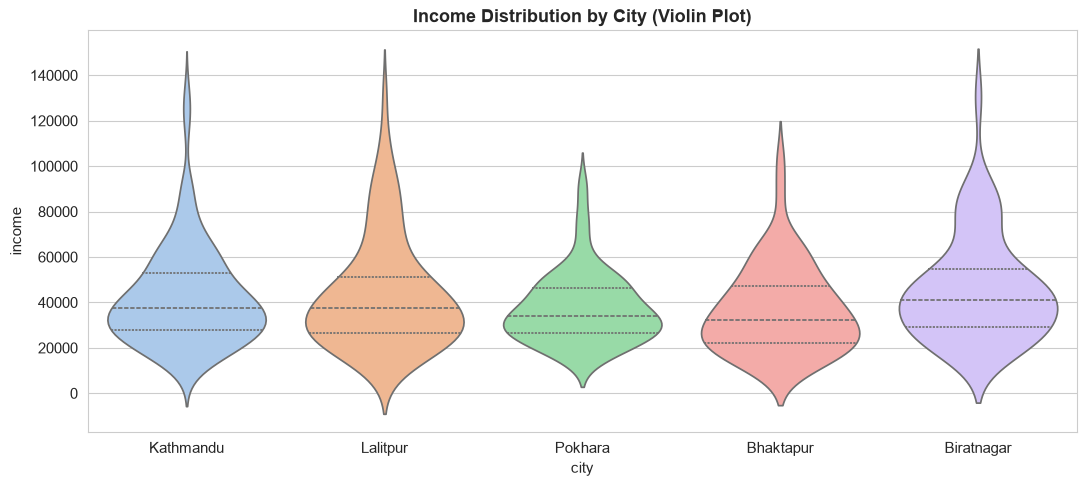

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=demo, x='city', y='income', ax=ax,
               order=demo['city'].value_counts().index, palette='pastel', inner='quartile')
ax.set_title('Income Distribution by City (Violin Plot)')
plt.tight_layout()
plt.show()

**Reading the chart:** The shape tells you where customers concentrate. A pinched middle would suggest a bimodal income distribution; a long upper tail means a few high earners.

---
# 2️⃣ Bivariate Analysis — Two Variables Together

Now we look at **relationships between pairs** of variables. The chart depends on the variable types:

| Variable A | Variable B | Best chart |
|-----------|-----------|-----------|
| Numerical | Numerical | Scatter, line, hexbin |
| Numerical | Categorical | Box, violin, grouped bar |
| Categorical | Categorical | Grouped bar, stacked bar, heatmap |


## 2.1 ⚫ Scatter Plot

### What it does
Each point represents an observation, placed by its values on two numerical axes.

### When to use
- Two numerical variables, you want to spot a **relationship**
- You're looking for **correlation**, **clusters**, or **outliers**
- You want to check whether a relationship is linear, curved, or non-existent

### What to look for
- **Direction** — positive (up-right), negative (down-right), or no trend
- **Strength** — tight cloud (strong) vs. wide scatter (weak)
- **Shape** — straight line (linear) vs. curve (non-linear)


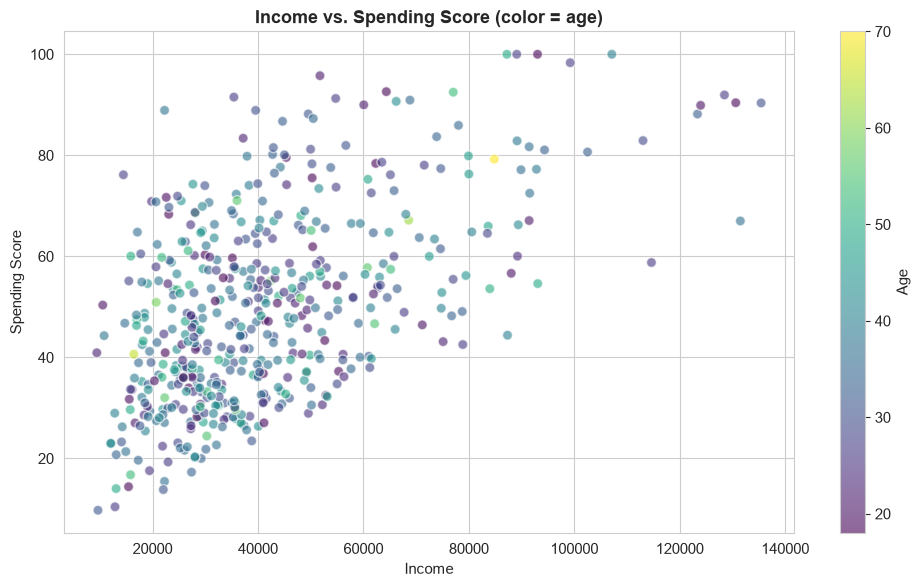

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(demo['income'], demo['spending_score'],
                     c=demo['age'], cmap='viridis', alpha=0.6, edgecolor='white', s=50)
ax.set_xlabel('Income')
ax.set_ylabel('Spending Score')
ax.set_title('Income vs. Spending Score (color = age)')
plt.colorbar(scatter, label='Age')
plt.tight_layout()
plt.show()

## 2.2 📈 Line Chart

### What it does
Connects sequential data points with a line — great for showing **trends over an ordered variable**, most often time.

### When to use
- The x-axis is **ordered** (dates, time, sequence, dosage)
- You're tracking how a value **changes**
- You're comparing trends across a few series (use different colors)

### Don't use it when
- The x-axis is categorical and unordered — a line implies continuity, which would be misleading


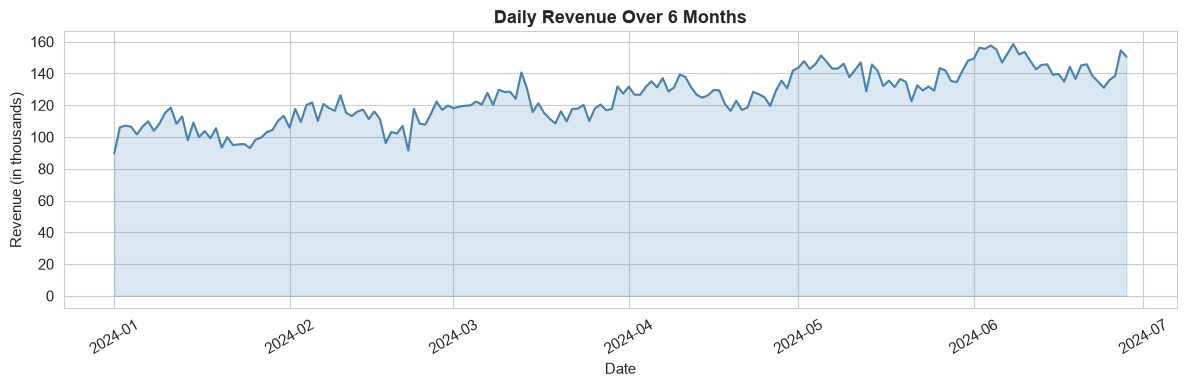

In [15]:
# Synthetic time series: daily revenue
dates = pd.date_range('2024-01-01', periods=180, freq='D')
trend = np.linspace(100, 150, 180)
seasonal = 10 * np.sin(np.linspace(0, 12*np.pi, 180))
noise = np.random.normal(0, 5, 180)
revenue = trend + seasonal + noise

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, revenue, color='steelblue', linewidth=1.5)
ax.fill_between(dates, revenue, alpha=0.2, color='steelblue')
ax.set_title('Daily Revenue Over 6 Months')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (in thousands)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 2.3 ⬡ Hexbin Plot

### What it does
A **2D histogram in hexagonal bins**. Each hexagon's color shows how many points fall inside it.

### When to use
- You have **a lot of data** (thousands of points)
- A regular scatter plot becomes a black blob with overplotting
- You want to see **density** rather than individual points


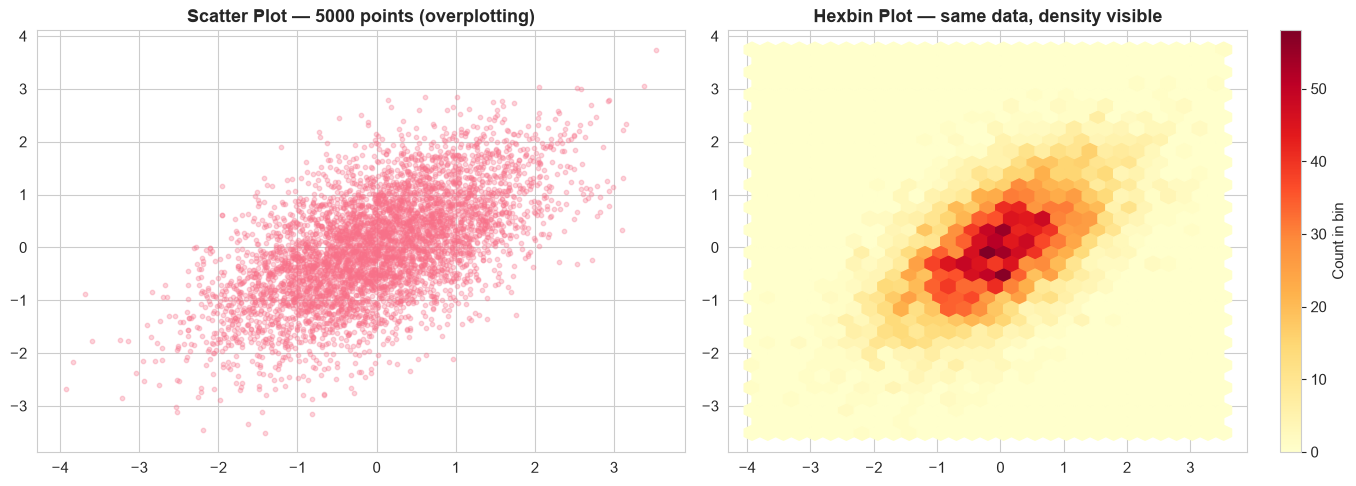

In [16]:
# Generate more data to show the value of hexbin
big_x = np.random.normal(0, 1, 5000)
big_y = big_x * 0.6 + np.random.normal(0, 0.8, 5000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(big_x, big_y, alpha=0.3, s=10)
axes[0].set_title('Scatter Plot — 5000 points (overplotting)')

hb = axes[1].hexbin(big_x, big_y, gridsize=30, cmap='YlOrRd')
axes[1].set_title('Hexbin Plot — same data, density visible')
plt.colorbar(hb, ax=axes[1], label='Count in bin')

plt.tight_layout()
plt.show()

## 2.4 🔗 Joint Plot

### What it does
Combines a **scatter plot with the marginal distributions** (histograms or KDEs) of each variable along the axes.

### When to use
- You want the relationship **and** the individual distributions at a glance
- Great for one-shot exploratory analysis of two numerical variables


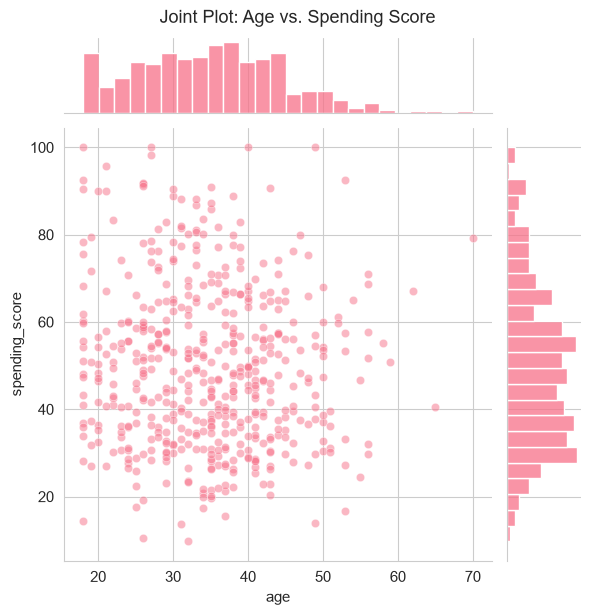

In [17]:
g = sns.jointplot(data=demo, x='age', y='spending_score',
                  kind='scatter', height=6, alpha=0.5,
                  marginal_kws=dict(bins=25, fill=True))
g.fig.suptitle('Joint Plot: Age vs. Spending Score', y=1.02)
plt.show()

## 2.5 📊 Grouped & Stacked Bar Chart

### What it does
Bars split or stacked by a **second categorical variable**, letting you compare across two dimensions at once.

- **Grouped** — bars sit next to each other → best for comparing **values within groups**
- **Stacked** — bars sit on top of each other → best for showing **composition / part-to-whole**


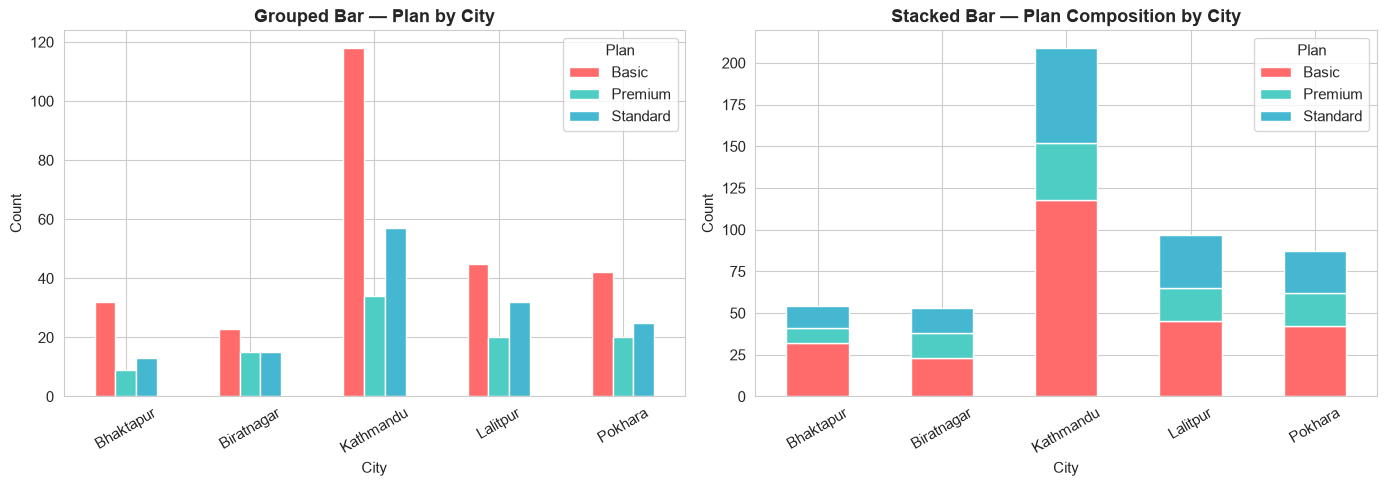

In [18]:
ct = pd.crosstab(demo['city'], demo['plan'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='white')
axes[0].set_title('Grouped Bar — Plan by City')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Count')
axes[0].legend(title='Plan')
axes[0].tick_params(axis='x', rotation=30)

ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='white')
axes[1].set_title('Stacked Bar — Plan Composition by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Count')
axes[1].legend(title='Plan')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
# 3️⃣ Multivariate Analysis — Three or More Variables

Once you go beyond two variables, you need techniques that compress information cleverly. The classics:


## 3.1 🔥 Heatmap (Correlation Matrix)

### What it does
A grid where the **color of each cell encodes a value** — most often, the correlation between every pair of numerical variables.

### When to use
- You want a **fast overview** of pairwise relationships in a dataset
- You're spotting variables that move together (good for feature selection / multicollinearity checks)

### How to read a correlation heatmap
- **+1** → perfect positive correlation (one goes up, the other goes up)
- **0** → no linear relationship
- **-1** → perfect negative correlation
- Diagonal is always 1 (a variable with itself)


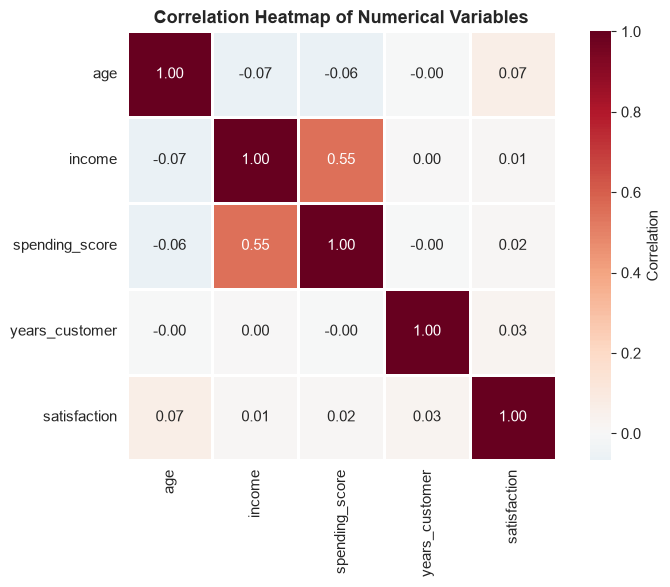

In [19]:
corr = demo[['age', 'income', 'spending_score', 'years_customer', 'satisfaction']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

## 3.2 🧩 Pair Plot (Scatter Plot Matrix)

### What it does
A grid showing a **scatter plot for every pair** of numerical variables, with each variable's **distribution on the diagonal**.

### When to use
- Early exploration — get the whole picture in one shot
- You want to spot relationships, clusters, and distributions all at once
- Color by a categorical variable to see how it interacts with everything else

### Caveat
- Grows as O(n²) with the number of variables — keep to ≤ ~7 columns


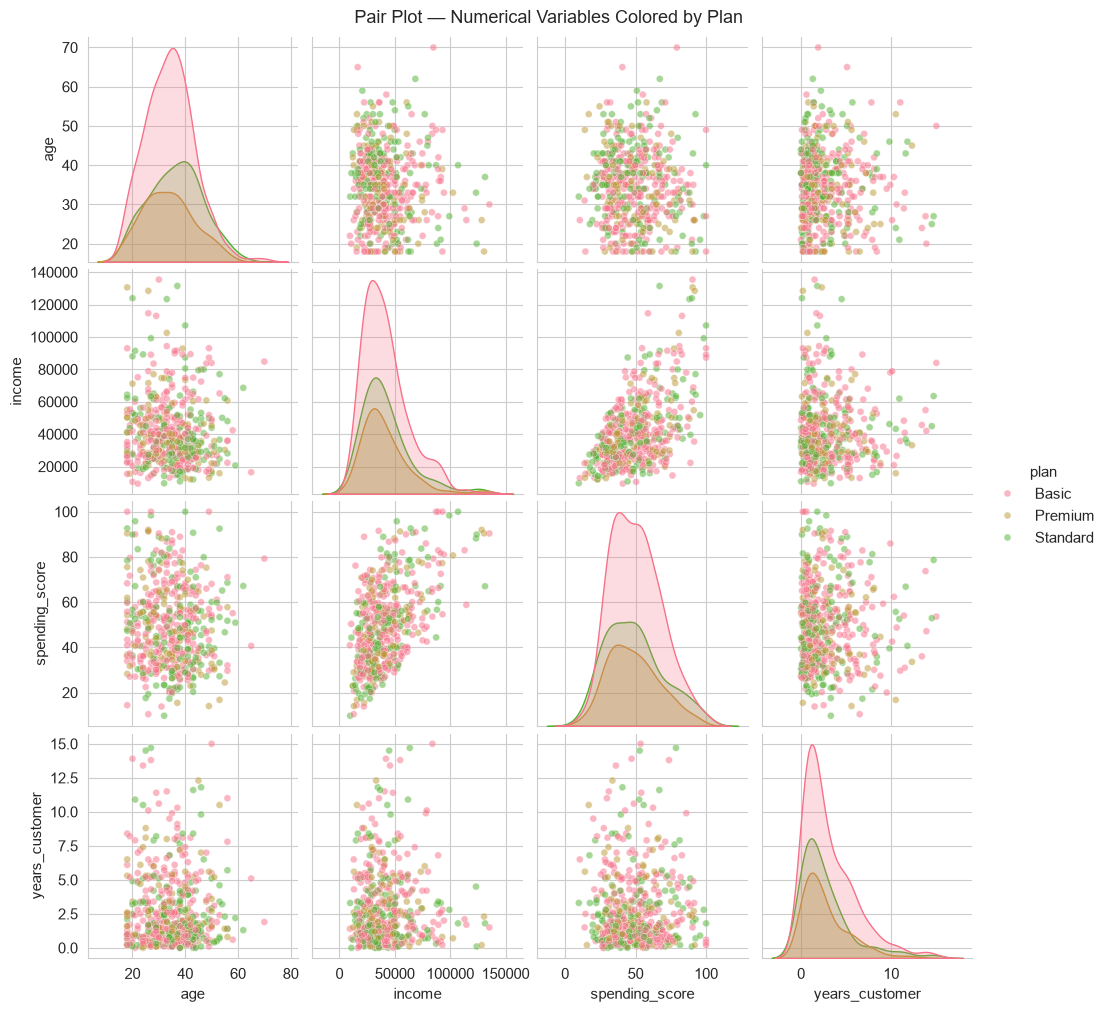

In [20]:
sns.pairplot(demo[['age', 'income', 'spending_score', 'years_customer', 'plan']],
             hue='plan', diag_kind='kde', plot_kws={'alpha': 0.5, 's': 25})
plt.suptitle('Pair Plot — Numerical Variables Colored by Plan', y=1.01)
plt.show()

## 3.3 🫧 Bubble Chart

### What it does
A scatter plot where the **size of each point encodes a third variable**. With color you can fit a fourth.

### When to use
- Three or four variables, you want them all in one view
- Often used in business dashboards (e.g., revenue vs. growth, bubble size = market share)


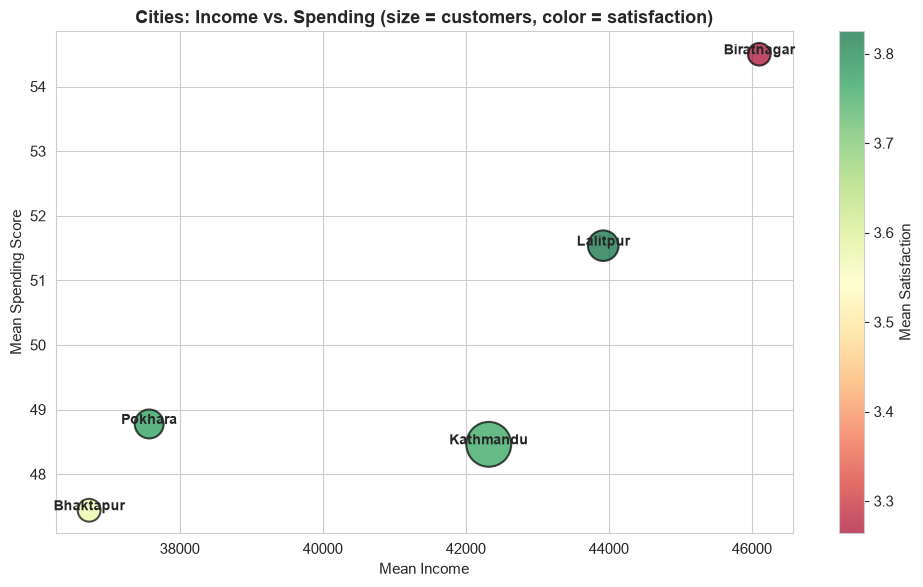

In [21]:
# Aggregate to city level for clean bubbles
agg = demo.groupby('city').agg(
    mean_income=('income', 'mean'),
    mean_spending=('spending_score', 'mean'),
    customers=('age', 'count'),
    mean_satisfaction=('satisfaction', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(agg['mean_income'], agg['mean_spending'],
                s=agg['customers']*5, c=agg['mean_satisfaction'],
                cmap='RdYlGn', alpha=0.7, edgecolor='black', linewidth=1.5)
for _, row in agg.iterrows():
    ax.annotate(row['city'], (row['mean_income'], row['mean_spending']),
                ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Mean Income')
ax.set_ylabel('Mean Spending Score')
ax.set_title('Cities: Income vs. Spending (size = customers, color = satisfaction)')
plt.colorbar(sc, label='Mean Satisfaction')
plt.tight_layout()
plt.show()

## 3.4 🧊 3D Scatter Plot (Use Sparingly)

### What it does
Plots three numerical variables on x, y, and z axes.

### When to use
- You **really** need to show three numerical dimensions and 2D alternatives won't do
- For interactive exploration (Plotly is better than matplotlib for this)

### Caveats
- Hard to read on a static page — points overlap, depth is ambiguous
- Often a pair plot or bubble chart communicates the same information more clearly


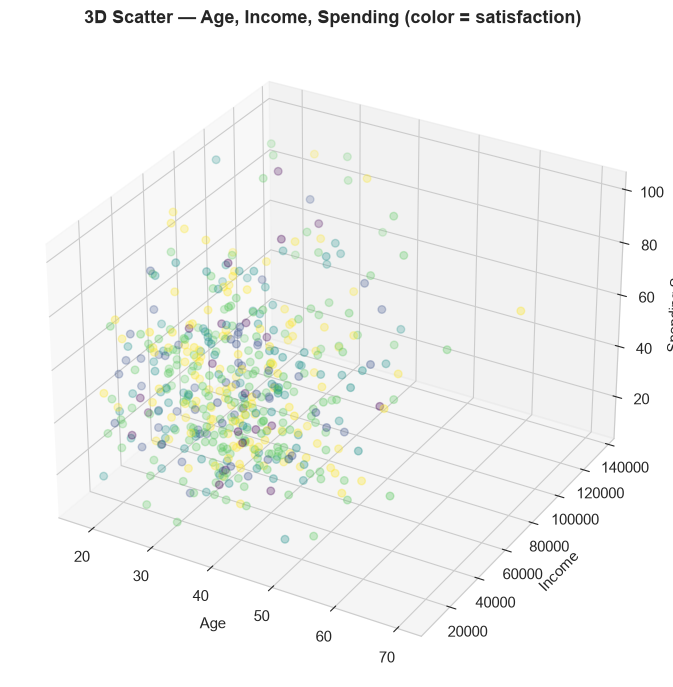

In [22]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(demo['age'], demo['income'], demo['spending_score'],
           c=demo['satisfaction'], cmap='viridis', alpha=0.6, s=30)
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Spending Score')
ax.set_title('3D Scatter — Age, Income, Spending (color = satisfaction)')
plt.tight_layout()
plt.show()

---
# 4️⃣ Descriptive Analysis on a Messy Dataset

Now we apply everything to a **realistic, messy dataset** of employee records. Real data almost never arrives clean — it has missing values, typos, inconsistent capitalization, mixed types, duplicates, and outliers. This is the workflow you'll repeat for the rest of your data career.

## The Workflow
1. **Load & inspect** — look at the data, identify problems
2. **Clean** — handle missing values, fix types, remove duplicates, standardize categories
3. **Describe** — compute summary statistics
4. **Visualize** — explore patterns with the charts above
5. **Conclude** — extract insights


## 4.1 Building the Messy Dataset

We construct a deliberately messy employee dataset that contains every problem you typically face in the wild.

In [23]:
np.random.seed(0)
n = 250

departments_messy = np.random.choice(
    ['Engineering', 'engineering', 'ENGINEERING', ' Engineering ',
     'Sales', 'sales', 'SALES', 'Marketing', 'marketing',
     'HR', 'hr', 'Human Resources', 'Finance', 'finance'],
    n, p=[0.08,0.08,0.06,0.03,0.10,0.08,0.05,0.08,0.06,0.06,0.04,0.04,0.14,0.10]
)

ages = np.random.normal(35, 8, n)
# Inject errors: a few negative ages (typos) and impossible ages
ages[5] = -25
ages[40] = 200
ages[100] = -1
ages = np.round(ages, 0)

salaries = np.random.lognormal(10.7, 0.45, n).round(0)
salaries[20] = 9_999_999  # one huge outlier
salaries[80] = 0  # impossible value

# Salaries stored as strings (very common from CSV imports!)
salary_strings = [f"${s:,.0f}" if i % 4 != 0 else str(int(s)) for i, s in enumerate(salaries)]

# Hire dates with inconsistent formats
date_formats = ['%Y-%m-%d', '%d/%m/%Y', '%m-%d-%Y', '%b %d, %Y']
base = datetime(2015, 1, 1)
hire_dates = []
for i in range(n):
    d = base + timedelta(days=np.random.randint(0, 3500))
    hire_dates.append(d.strftime(date_formats[i % 4]))

# Performance score with missing values represented inconsistently
perf = np.random.normal(75, 12, n).round(1)
perf_mixed = []
for i, p in enumerate(perf):
    if i % 15 == 0: perf_mixed.append(np.nan)
    elif i % 23 == 0: perf_mixed.append('?')
    elif i % 31 == 0: perf_mixed.append('N/A')
    elif i % 37 == 0: perf_mixed.append('unknown')
    else: perf_mixed.append(p)

# Emails — some valid, some malformed
def email_for(i):
    if i % 19 == 0: return None
    if i % 17 == 0: return 'invalid_email'
    if i % 13 == 0: return f'  Employee{i}@COMPANY.COM  '
    return f'employee{i}@company.com'

messy = pd.DataFrame({
    'employee_id': [f'E{i:04d}' for i in range(n)],
    'name': [f'Employee {i}' for i in range(n)],
    'age': ages,
    'department': departments_messy,
    'salary': salary_strings,
    'hire_date': hire_dates,
    'performance_score': perf_mixed,
    'email': [email_for(i) for i in range(n)],
    'is_remote': np.random.choice(['Yes', 'No', 'yes', 'no', 'Y', 'N', '1', '0', None],
                                   n, p=[0.20, 0.20, 0.12, 0.12, 0.10, 0.10, 0.05, 0.05, 0.06]),
})

# Add duplicate rows
duplicates = messy.sample(8, random_state=1)
messy = pd.concat([messy, duplicates], ignore_index=True)

# Add some entirely missing rows in key columns
missing_idx = np.random.choice(messy.index, 12, replace=False)
messy.loc[missing_idx[:6], 'age'] = np.nan
messy.loc[missing_idx[6:], 'salary'] = np.nan

print(f"Messy dataset shape: {messy.shape}")
messy.head(10)

Messy dataset shape: (258, 9)


,employee_id,name,age,department,salary,hire_date,performance_score,email,is_remote
0,E0000,Employee 0,39.0,Marketing,65784,2015-12-22,NaN,NaN,No
1,E0001,Employee 1,34.0,hr,"$42,117",04/01/2023,84.4,employee1@company.com,No
2,E0002,Employee 2,41.0,marketing,"$54,494",09-17-2019,74.3,employee2@company.com,Y
3,E0003,Employee 3,42.0,Marketing,"$28,737","Sep 27, 2019",70.3,employee3@company.com,Yes
4,E0004,Employee 4,52.0,sales,31189,2022-10-07,86.3,employee4@company.com,1
5,E0005,Employee 5,-25.0,HR,"$42,206",09/10/2023,79.9,employee5@company.com,yes
6,E0006,Employee 6,32.0,SALES,"$27,596",03-23-2015,81.0,employee6@company.com,yes
7,E0007,Employee 7,33.0,Finance,"$64,158","Mar 08, 2023",74.7,employee7@company.com,no
8,E0008,Employee 8,44.0,finance,54634,2020-09-17,54.7,employee8@company.com,Y
9,E0009,Employee 9,40.0,sales,"$50,292",12/07/2023,73.7,employee9@company.com,No


## 4.2 Initial Inspection — What's Wrong?

The first move with any dataset: just *look* at it. Use `.info()`, `.describe()`, and `.head()`.

In [24]:
print('=' * 50)
print('DATA TYPES & MISSING VALUES')
print('=' * 50)
messy.info()

DATA TYPES & MISSING VALUES
<class 'pandas.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        258 non-null    str    
 1   name               258 non-null    str    
 2   age                252 non-null    float64
 3   department         258 non-null    str    
 4   salary             252 non-null    str    
 5   hire_date          258 non-null    str    
 6   performance_score  241 non-null    object 
 7   email              244 non-null    str    
 8   is_remote          238 non-null    str    
dtypes: float64(1), object(1), str(7)
memory usage: 34.5+ KB


In [25]:
print('=' * 50)
print('MISSING VALUE COUNTS')
print('=' * 50)
print(messy.isna().sum())
print(f'\nTotal duplicate rows: {messy.duplicated().sum()}')

MISSING VALUE COUNTS
employee_id           0
name                  0
age                   6
department            0
salary                6
hire_date             0
performance_score    17
email                14
is_remote            20
dtype: int64

Total duplicate rows: 7


In [26]:
print('=' * 50)
print('UNIQUE VALUES IN CATEGORICAL COLUMNS')
print('=' * 50)
print('\nDepartments (notice the inconsistencies!):')
print(messy['department'].value_counts())
print('\nis_remote (notice the chaos!):')
print(messy['is_remote'].value_counts(dropna=False))

UNIQUE VALUES IN CATEGORICAL COLUMNS

Departments (notice the inconsistencies!):
department
Finance            29
marketing          28
Sales              24
engineering        22
finance            21
ENGINEERING        20
sales              19
Engineering        19
HR                 17
SALES              16
Marketing          14
hr                 14
Human Resources     9
 Engineering        6
Name: count, dtype: int64

is_remote (notice the chaos!):
is_remote
Yes    49
No     48
Y      33
yes    28
no     24
N      23
NaN    20
0      19
1      14
Name: count, dtype: int64


### Problems We've Found

| Column | Problem |
|--------|---------|
| `age` | Missing values, impossible values (-25, 200, -1) |
| `department` | Same value with different capitalization & whitespace |
| `salary` | Stored as **string** with `$` and commas — can't do math, plus extreme outliers |
| `hire_date` | **Four different date formats** mixed together |
| `performance_score` | Missing values encoded as `NaN`, `'?'`, `'N/A'`, `'unknown'` |
| `email` | Mixed case, leading/trailing whitespace, invalid entries |
| `is_remote` | Yes / No / Y / N / 1 / 0 / yes / no — 8 versions of binary! |
| (rows) | 8 duplicate rows |


## 4.3 Cleaning Step-by-Step

In [27]:
df = messy.copy()
print(f'Starting rows: {len(df)}')

# 1. Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print(f'After dropping duplicates: {len(df)}')

# 2. Standardize department
df['department'] = df['department'].str.strip().str.title()
df['department'] = df['department'].replace({'Hr': 'HR', 'Human Resources': 'HR'})
print('\nCleaned departments:')
print(df['department'].value_counts())

Starting rows: 258
After dropping duplicates: 251

Cleaned departments:
department
Engineering    64
Sales          56
Finance        50
Marketing      42
HR             39
Name: count, dtype: int64


In [28]:
# 3. Clean salary: strip $ and commas, convert to float
df['salary'] = (df['salary'].astype(str)
                .str.replace('$', '', regex=False)
                .str.replace(',', '', regex=False)
                .str.strip())
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

# Flag impossible values (will treat as missing)
df.loc[df['salary'] == 0, 'salary'] = np.nan
# Flag extreme outlier as missing — beyond a sensible cap
df.loc[df['salary'] > 1_000_000, 'salary'] = np.nan
print(f"Salary after cleaning -> dtype: {df['salary'].dtype}, missing: {df['salary'].isna().sum()}")

Salary after cleaning -> dtype: float64, missing: 7


In [29]:
# 4. Fix age — impossible values become NaN
df.loc[(df['age'] < 18) | (df['age'] > 80), 'age'] = np.nan
print(f"Age after cleaning — missing: {df['age'].isna().sum()}, range: {df['age'].min():.0f}–{df['age'].max():.0f}")

Age after cleaning — missing: 12, range: 18–53


In [30]:
# 5. Parse hire_date with mixed formats
def parse_date(s):
    for fmt in ['%Y-%m-%d', '%d/%m/%Y', '%m-%d-%Y', '%b %d, %Y']:
        try:
            return datetime.strptime(s, fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df['hire_date'] = df['hire_date'].apply(parse_date)
df['hire_date'] = pd.to_datetime(df['hire_date'])
df['years_at_company'] = (pd.Timestamp.today() - df['hire_date']).dt.days / 365.25
print(f"Hire date dtype: {df['hire_date'].dtype}")
print(f"Date range: {df['hire_date'].min().date()} to {df['hire_date'].max().date()}")

Hire date dtype: datetime64[us]
Date range: 2015-01-17 to 2024-07-15


In [31]:
# 6. Clean performance_score — convert non-numeric placeholders to NaN
df['performance_score'] = pd.to_numeric(df['performance_score'], errors='coerce')
print(f"Performance score — missing: {df['performance_score'].isna().sum()}")

Performance score — missing: 41


In [32]:
# 7. Standardize is_remote to actual booleans
remote_map = {
    'Yes': True, 'yes': True, 'Y': True, '1': True,
    'No': False, 'no': False, 'N': False, '0': False
}
df['is_remote'] = df['is_remote'].map(remote_map)
print(f"is_remote — True: {df['is_remote'].sum()}, False: {(df['is_remote']==False).sum()}, Missing: {df['is_remote'].isna().sum()}")

is_remote — True: 120, False: 111, Missing: 20


In [33]:
# 8. Clean email — lowercase, strip whitespace, flag invalids
df['email'] = df['email'].astype(str).str.strip().str.lower()
df.loc[~df['email'].str.contains('@', na=False), 'email'] = np.nan
df.loc[df['email'] == 'none', 'email'] = np.nan

# 9. Impute remaining numerical missing values with median (a common simple choice)
for col in ['age', 'salary', 'performance_score']:
    df[col] = df[col].fillna(df[col].median())

print('\n✅ Cleaning complete!')
print(f'Final shape: {df.shape}')
print(f'Remaining missing values:\n{df.isna().sum()}')


✅ Cleaning complete!
Final shape: (251, 10)
Remaining missing values:
employee_id           0
name                  0
age                   0
department            0
salary                0
hire_date             0
performance_score     0
email                28
is_remote            20
years_at_company      0
dtype: int64


## 4.4 Descriptive Statistics on the Cleaned Data

In [34]:
df.describe(include='all').round(2)

,employee_id,name,age,department,salary,hire_date,performance_score,email,is_remote,years_at_company
count,251,251,251.00,251,251.00,251,251.00,223,231,251.00
unique,250,250,NaN,5,NaN,NaN,NaN,222,2,NaN
top,E0249,Employee 249,NaN,Engineering,NaN,NaN,NaN,employee249@company.com,True,NaN
freq,2,2,NaN,64,NaN,NaN,NaN,2,120,NaN
mean,NaN,NaN,34.67,NaN,46455.38,2019-08-21 10:54:01.434263,75.93,NaN,NaN,6.89
min,NaN,NaN,18.00,NaN,11263.00,2015-01-17 00:00:00,44.00,NaN,NaN,1.99
25%,NaN,NaN,30.00,NaN,31337.50,2017-03-18 12:00:00,70.10,NaN,NaN,4.66
50%,NaN,NaN,35.00,NaN,42708.50,2019-09-17 00:00:00,75.60,NaN,NaN,6.81
75%,NaN,NaN,40.00,NaN,54671.50,2021-11-13 00:00:00,80.25,NaN,NaN,9.31
max,NaN,NaN,53.00,NaN,149238.00,2024-07-15 00:00:00,108.10,NaN,NaN,11.48


### Key takeaways from the summary statistics
- We can now compute meaningful statistics — before cleaning, `salary` was a string and `age` was contaminated with -25 and 200
- The **median is more reliable than the mean** for skewed columns like salary
- We can see the typical age, salary, tenure, and performance ranges at a glance


## 4.5 Visualizing the Cleaned Data

### 4.5.1 Distribution of every numerical variable (Histograms + Box plots)

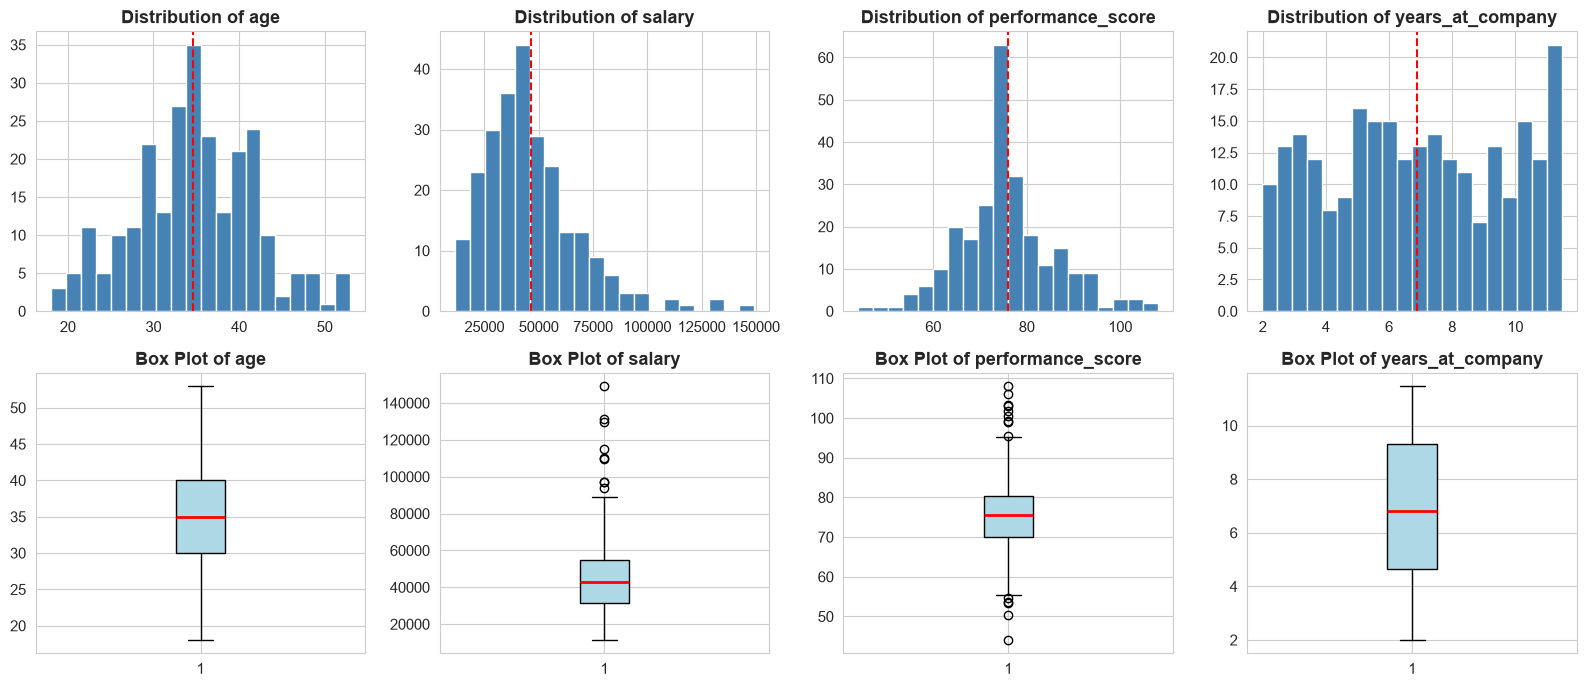

In [35]:
num_cols = ['age', 'salary', 'performance_score', 'years_at_company']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'Distribution of {col}')
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5)

    axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

### 4.5.2 Categorical breakdowns (Bar charts)

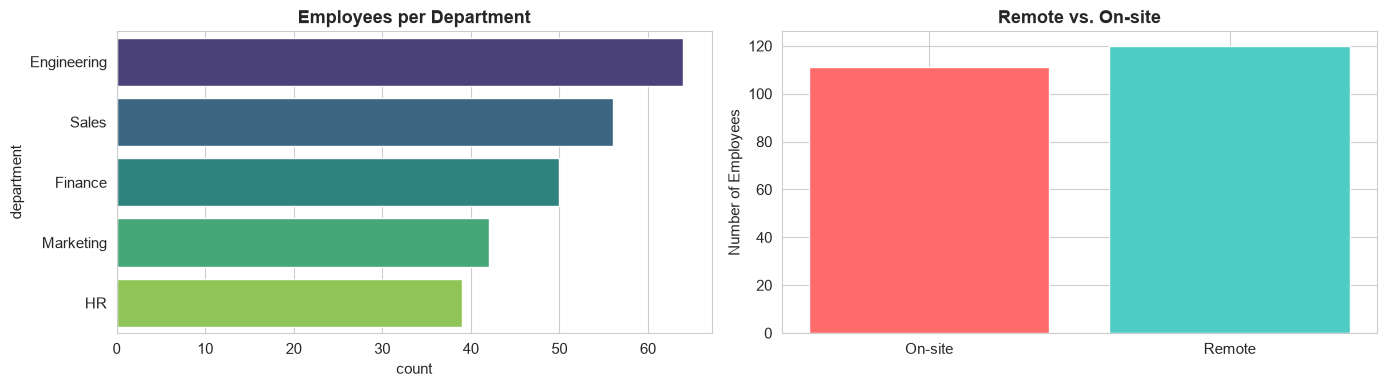

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dept_order = df['department'].value_counts().index
sns.countplot(data=df, y='department', order=dept_order, ax=axes[0], palette='viridis')
axes[0].set_title('Employees per Department')

remote_counts = df['is_remote'].value_counts()
axes[1].bar(['On-site', 'Remote'], [remote_counts.get(False, 0), remote_counts.get(True, 0)],
            color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[1].set_title('Remote vs. On-site')
axes[1].set_ylabel('Number of Employees')

plt.tight_layout()
plt.show()

### 4.5.3 Salary by Department (Box plot — great for comparing groups)

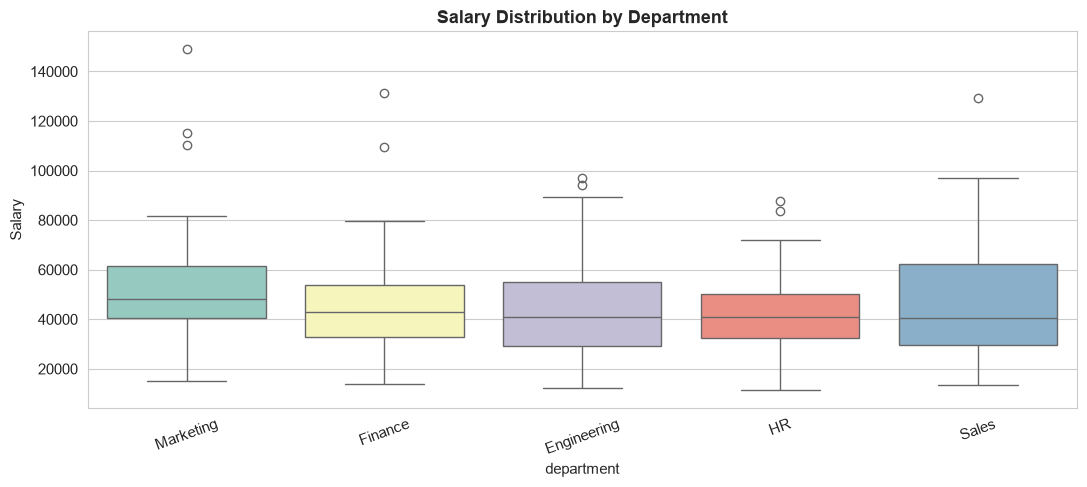

In [37]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='department', y='salary',
            order=df.groupby('department')['salary'].median().sort_values(ascending=False).index,
            palette='Set3', ax=ax)
ax.set_title('Salary Distribution by Department')
ax.set_ylabel('Salary')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 4.5.4 Relationships between numerical variables (Pair plot)

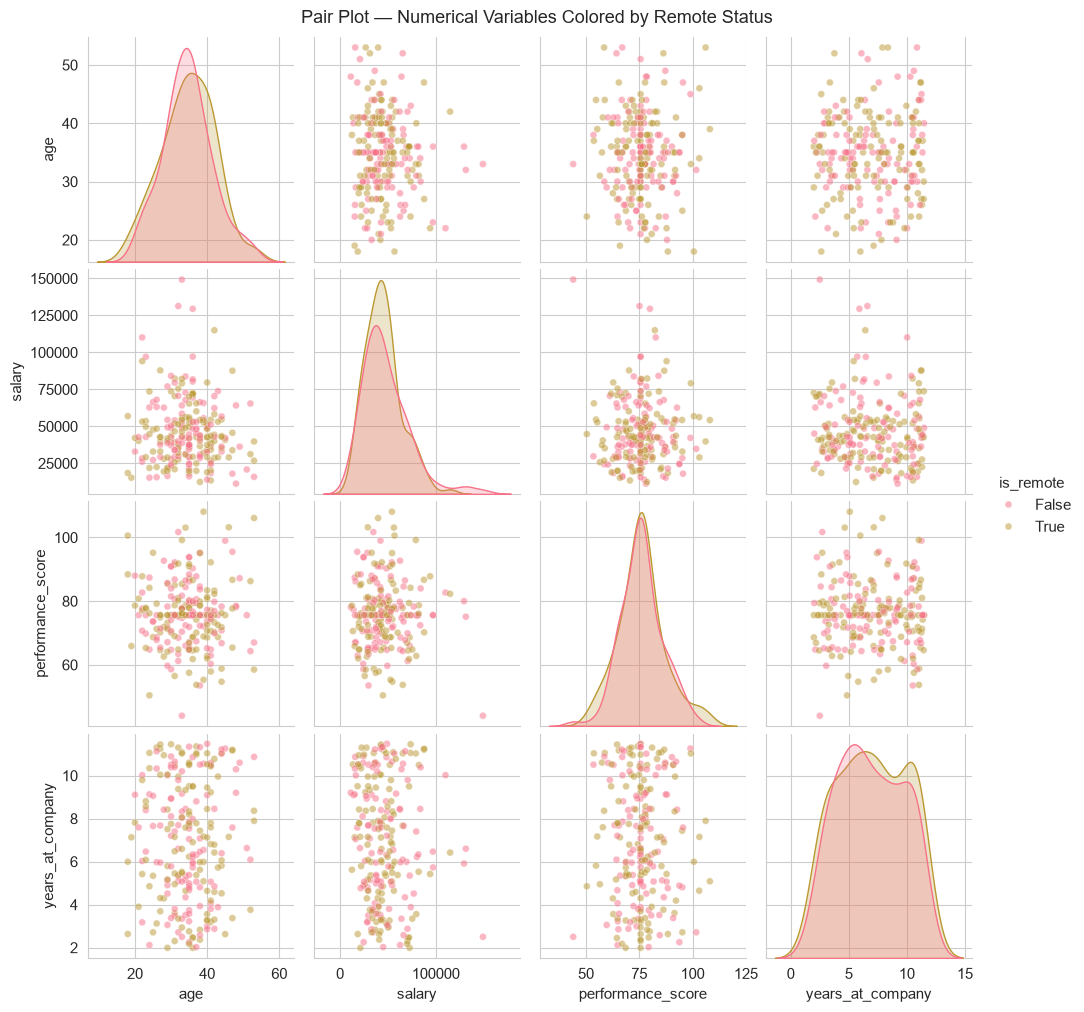

In [38]:
sns.pairplot(df[num_cols + ['is_remote']].dropna(),
             hue='is_remote', diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 25})
plt.suptitle('Pair Plot — Numerical Variables Colored by Remote Status', y=1.01)
plt.show()

### 4.5.5 Correlation Heatmap

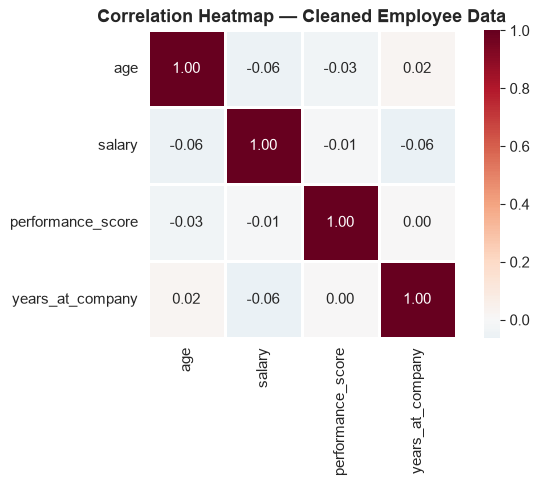

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Heatmap — Cleaned Employee Data')
plt.tight_layout()
plt.show()

### 4.5.6 Performance by Department & Remote Status (Violin + grouped)

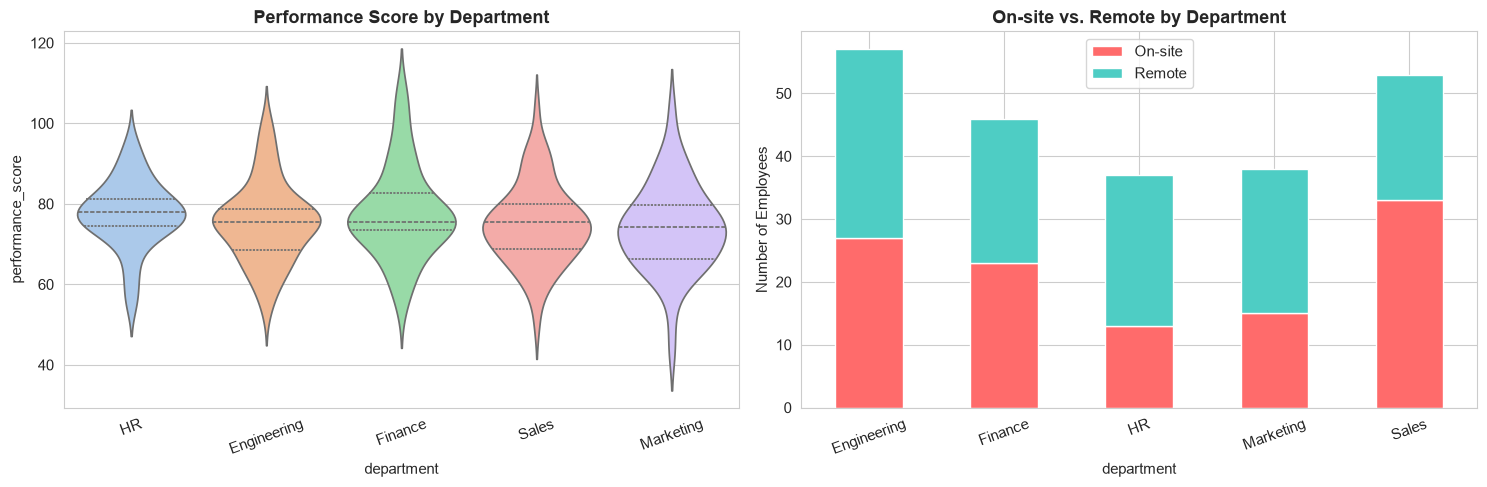

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.violinplot(data=df, x='department', y='performance_score', ax=axes[0],
               palette='pastel', inner='quartile',
               order=df.groupby('department')['performance_score'].median().sort_values(ascending=False).index)
axes[0].set_title('Performance Score by Department')
axes[0].tick_params(axis='x', rotation=20)

remote_dept = df.groupby(['department', 'is_remote']).size().unstack(fill_value=0)
remote_dept.plot(kind='bar', stacked=True, ax=axes[1],
                 color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[1].set_title('On-site vs. Remote by Department')
axes[1].set_ylabel('Number of Employees')
axes[1].legend(['On-site', 'Remote'])
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 4.6 Insights from the Descriptive Analysis

From the cleaned data and the visualizations above, we can summarize:

### Workforce Profile
- The dataset contains around **{n}** employees across **{d}** departments after cleaning and deduplication
- Average employee age is around **mid-30s**, with most between 28 and 42
- Salary distribution is **right-skewed** — most employees cluster in a middle range, with a tail of higher earners
- Tenure varies widely, from new hires to employees with nearly 10 years at the company

### Department Patterns
- Salary medians vary by department — the box plot makes the differences (and the spread within each) easy to spot
- Performance scores are reasonably similar across departments, with most scores clustered in the 65–85 range

### Correlations
- The correlation heatmap reveals weak-to-moderate relationships between the numerical variables — none are strongly redundant
- This is healthy for any downstream modeling — no severe multicollinearity

### Lessons from the Cleaning Process
What started as 258 messy rows with 8 different problems became a tidy, analyzable dataset. The key habits to take away:

1. **Always inspect raw data first** with `.info()`, `.head()`, and `.value_counts()` before computing anything
2. **Standardize categorical values** early — capitalization and whitespace are silent killers of `groupby()` operations
3. **Convert types intentionally** — money columns often arrive as strings, dates as inconsistent formats
4. **Treat impossible values as missing** rather than silently keeping them
5. **Document every cleaning decision** — your future self will thank you

---

## 🎯 Final Cheat Sheet

| Goal | Best chart |
|------|-----------|
| Shape of a numerical distribution | Histogram, KDE |
| Outliers and quartiles | Box plot |
| Frequencies of a categorical variable | Bar chart, count plot |
| Proportions of a small number of categories | Pie chart (sparingly!) |
| Relationship between two numerical variables | Scatter plot |
| Trend over time | Line chart |
| Density when scatter overplots | Hexbin |
| Distribution + relationship together | Joint plot |
| Pairwise relationships among many variables | Pair plot |
| Correlations among many variables | Heatmap |
| Three numerical variables at once | Bubble chart |
| Distribution comparison across categories | Box plot, violin plot |
